# Разработка A/B-тестирования и анализ результатов

Вы работаете в компании развлекательного приложения с «бесконечной» лентой коротких видео. Основная цель продукта — удерживать внимание пользователя.

Монетизация приложения строится на двух моделях доступа к видео:

* Рекламная модель — бесплатный доступ к контенту, доход приносят рекламные ролики, встроенные в ленту.
* Подписочная модель — ежемесячная оплата, которая полностью отключает рекламу и делает просмотр беспрерывным.
Главный двигатель вашего приложения — это алгоритм рекомендаций.


>Рекомендательная система — это алгоритм, который из миллионов доступных вариантов выбирает те, которые с наибольшей вероятностью понравятся конкретному пользователю.
>Если алгоритм в приложении для коротких видео будет работать плохо (то есть будет отбирать неинтересный контент), пользователь быстро его закроет. Если хорошо — это создаст для пользователя стимул остаться в приложении дольше, что напрямую влияет на выручку компании.


До недавнего времени лента формировалась на основе простых эвристик, по схеме «популярное за день + новинки». Сейчас всё меняется: команда Data Science разработала новый алгоритм ранжирования контента.

В отличие от текущей системы, модель МО учитывает персональные интересы пользователя: его прошлые отметки «Нравится» и длительность просмотра. Модель оптимизирована на предсказание вероятности глубокого вовлечения (просмотр более 80% видео). Таким образом, более релевантный контент должен увеличивать время пользователей в приложении. Однако есть два риска, которые могут негативно повлиять на доходы:

1. Пользователи без подписки, максимально поглощённые релевантным контентом, могут начать негативно реагировать на рекламные вставки.
2. Ценность платной подписки «без рекламы» снизится, если контент станет слишком поглощающим.


## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### Импорт необходимых библиотек и методов

В этой ячейке импортируйте все необходимые библиотеки и функции, которые понадобятся нам для проведения A/B-теста и расчётов.

Обратите внимание: часть импортов вам нужно будет дополнить самостоятельно.

In [1]:
# Импорт инструментов для расчёта мощности теста и эффекта
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# TODO: импортируйте функцию для округления вверх
from math import ceil

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


In [3]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
sessions_per_user = (
    sessions_history.groupby('user_id')['session_id']
    .nunique()
    .sort_values(ascending=False)
)
max_session_user = sessions_per_user.index[0]
print(f'Максимальное число уникальных сессий пользователя: {sessions_per_user.iloc[0]}')

Максимальное число уникальных сессий пользователя: 10


In [5]:
sessions_history.loc[sessions_history['user_id'].eq(max_session_user)].sort_values(
    ['session_start_ts', 'session_number']
)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

- Проанализируйте результаты этого этапа работы.


In [6]:
daily_stats = (
    sessions_history.groupby('session_date')
    .agg(
        total_users=('user_id', 'nunique'),
        registered_users=(
            'user_id',
            lambda ids: ids[sessions_history.loc[ids.index, 'registration_flag'].eq(1)].nunique()
        )
    )
    .sort_index()
)
daily_stats['registration_share'] = (daily_stats['registered_users'] / daily_stats['total_users'])
daily_stats.head()

,total_users,registered_users,registration_share
session_date,,,
2025-08-11,3919,169,0.043123
2025-08-12,6056,336,0.055482
2025-08-13,8489,464,0.054659
2025-08-14,10321,625,0.060556
2025-08-15,14065,840,0.059723


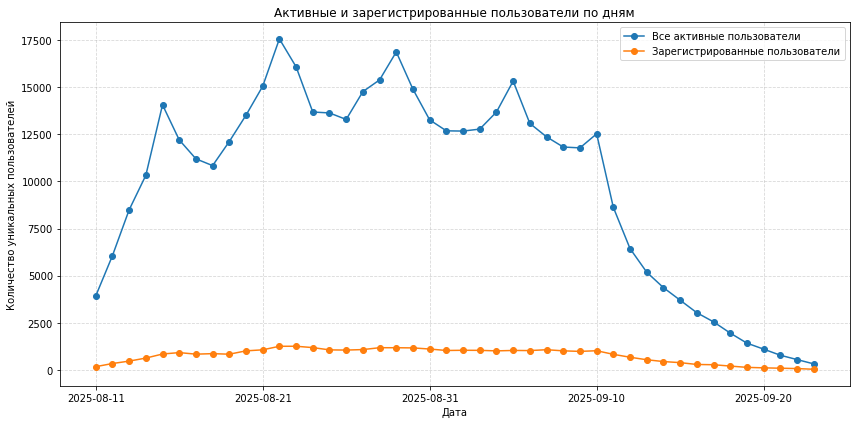

In [7]:
ax = daily_stats[['total_users', 'registered_users']].plot(
    figsize=(12, 6), marker='o'
)
ax.set_title('Активные и зарегистрированные пользователи по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество уникальных пользователей')
ax.legend(['Все активные пользователи', 'Зарегистрированные пользователи'])
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Количество активных пользователей стабильно в десятки раз превосходит общее количество активных пользователей. После 10/09/2025 количество активных и зарегистрировавшихся пользователей стало стремительно сокращаться, к 23/09/2025 количество и тех и других пользователй стало почти равно 0.

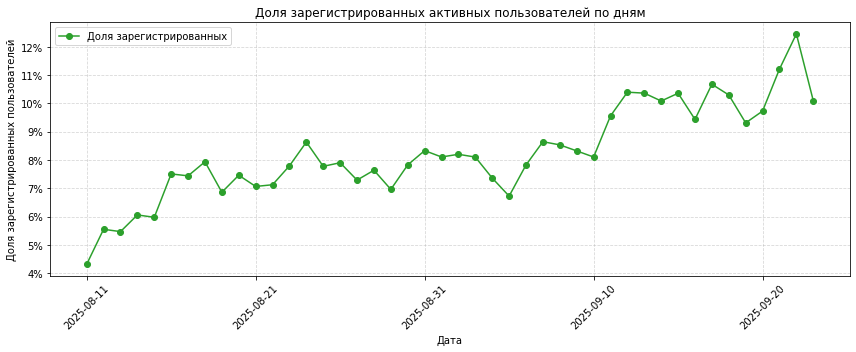

In [8]:
ax = daily_stats['registration_share'].plot(
    figsize=(12, 5), marker='o', color='tab:green'
)
ax.set_title('Доля зарегистрированных активных пользователей по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Доля зарегистрированных пользователей')
ax.yaxis.set_major_formatter(lambda value, position: f'{value:.0%}')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(['Доля зарегистрированных'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


С течением времени доля зарегистрированных пользователей увеличивается, также виден скачок в доле зарегистрированных пользователей с 10/09/2025, который объясняется уменьшением общего числа активных пользователей

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

- Проанализируйте результаты этого этапа работы.


In [9]:
first_sessions_history = (
    sessions_history.loc[sessions_history['session_number'].eq(1)]
    .drop_duplicates('session_id')
    .copy()
)

page_counts = (
    first_sessions_history['page_counter']
    .value_counts()
    .sort_index()
    .rename_axis('page_counter')
    .rename('sessions_count')
    .reset_index()
)
page_counts

,page_counter,sessions_count
0,1,8978
1,2,32494
2,3,50939
3,4,32739
4,5,8075
5,6,777
6,7,37


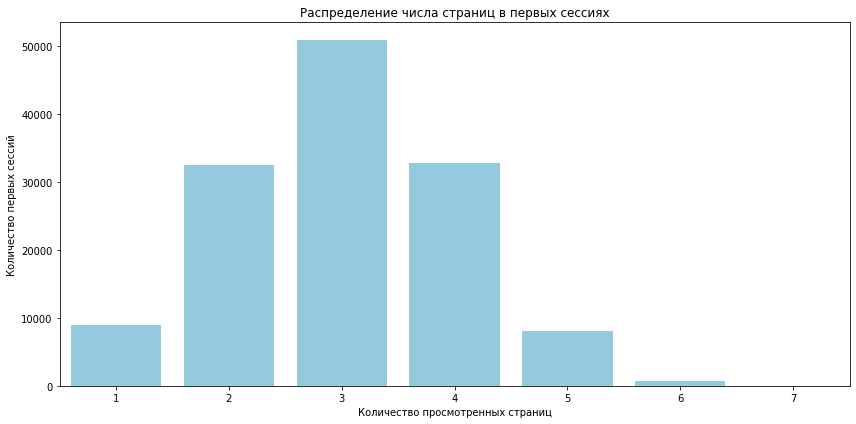

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=page_counts, x='page_counter', y='sessions_count', color='skyblue')
plt.title('Распределение числа страниц в первых сессиях')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Количество первых сессий')
plt.tight_layout()
plt.show()

Наиболее частое число просмотров в первой сессии - 3 страницы, примерно с равной частотой просматривают 2 и 3 страницы, а также 1 и 5 страниц, больше 5 страниц в первую сессию почти никто не просматривает

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

- Проанализируйте результаты этого этапа работы.


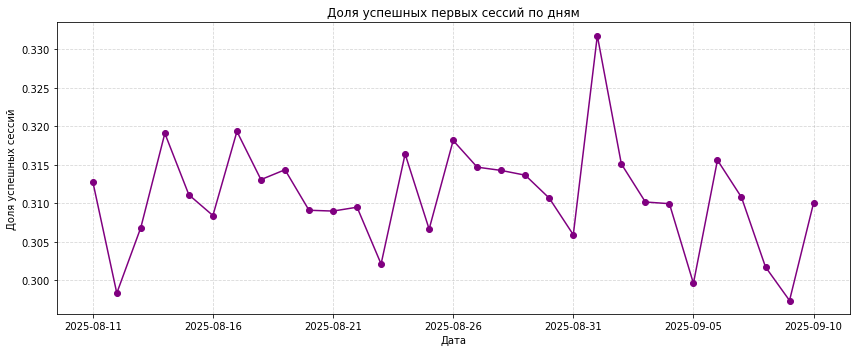

Средняя доля успешных первых сессий: 31.08%
Минимум: 29.74%; максимум: 33.18%


In [11]:
sessions_history['good_session'] = sessions_history['page_counter'].ge(4).astype(int)

daily_good_share = (
    sessions_history.loc[sessions_history['session_number'].eq(1)]
    .drop_duplicates('session_id')
    .groupby('session_date')['good_session']
    .mean()
)

ax = daily_good_share.plot(figsize=(12, 5), marker='o', color='purple')
ax.set_title('Доля успешных первых сессий по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Доля успешных сессий')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Средняя доля успешных первых сессий: {daily_good_share.mean():.2%}')
print(f'Минимум: {daily_good_share.min():.2%}; максимум: {daily_good_share.max():.2%}')


### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [12]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=power,
    alpha=alpha,
    ratio=1
)

sample_size_per_group = ceil(sample_size)
print(f'Необходимый размер каждой группы: {sample_size_per_group} пользователей')
print(f'Общий размер двух групп: {2*sample_size_per_group} пользователей')

Необходимый размер каждой группы: 41041 пользователей
Общий размер двух групп: 82082 пользователей


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [13]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = (sessions_history.groupby('session_date')['user_id'].nunique().mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2 * sample_size_per_group / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users:.1f} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.4 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [14]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')

In [15]:
monitoring_date = sessions_test_part['session_date'].min()
monitoring_day = sessions_test_part.loc[sessions_test_part['session_date'].eq(monitoring_date)]
group_counts = monitoring_day.groupby('test_group')['user_id'].nunique().sort_index()

group_counts

test_group
A    1477
B    1466
Name: user_id, dtype: int64

In [16]:
control_group = 'A' if 'A' in group_counts.index else group_counts.index[0]
test_group = 'B' if 'B' in group_counts.index else group_counts.index[1]
count_diff_pct = 100 * abs(group_counts[control_group] - group_counts[test_group]) / group_counts[control_group]

print(f'Разница между группами: {count_diff_pct:.2f}%')

Разница между группами: 0.74%


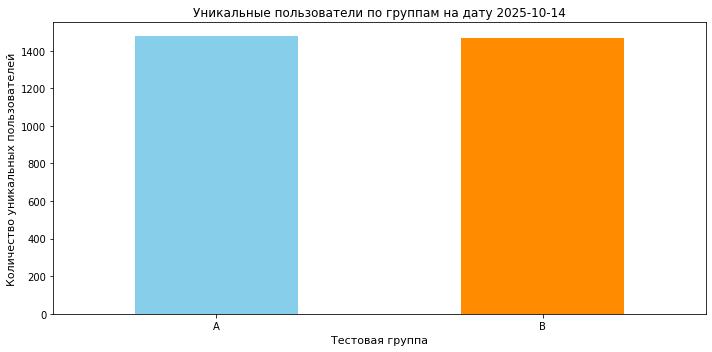

In [17]:
ax = group_counts.plot(kind='bar', color=['skyblue', 'darkorange'], figsize=(10, 5))
ax.set_title(f'Уникальные пользователи по группам на дату {monitoring_date}')
ax.set_xlabel('Тестовая группа', fontsize=11)
ax.set_ylabel('Количество уникальных пользователей', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [18]:
users_a = set(sessions_test_part.loc[sessions_test_part['test_group'].eq(control_group), 'user_id'])
users_b = set(sessions_test_part.loc[sessions_test_part['test_group'].eq(test_group), 'user_id'])
users_in_both_groups = users_a & users_b

print(f'Пользователей одновременно в группах {control_group} и {test_group}: {len(users_in_both_groups)}')

Пользователей одновременно в группах A и B: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


In [19]:
user_profiles = (
    sessions_test_part.sort_values('session_start_ts')
    .drop_duplicates(['test_group', 'user_id'])
)
device_shares = pd.crosstab(user_profiles['test_group'], user_profiles['device'], normalize='index')

device_shares

device,Android,Mac,PC,iPhone
test_group,,,,
A,0.444144,0.105619,0.249831,0.200406
B,0.455662,0.100955,0.259891,0.183492


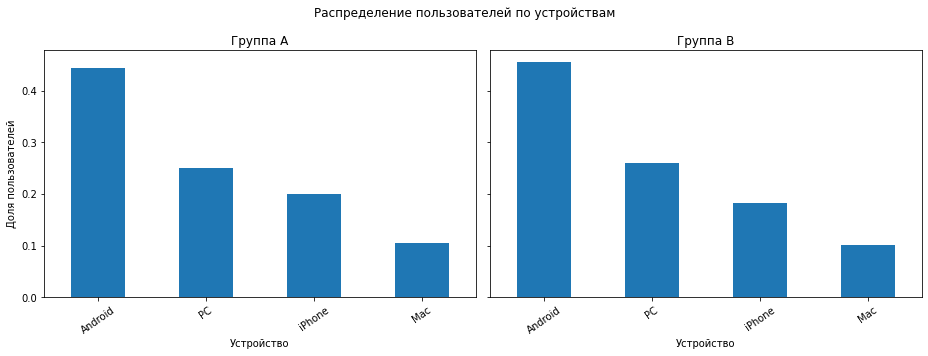

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, group in zip(axes, [control_group, test_group]):
    values = device_shares.loc[group].sort_values(ascending=False)
    values.plot(kind='bar', ax=ax)
    ax.set_title(f'Группа {group}')
    ax.set_xlabel('Устройство')
    ax.set_ylabel('Доля пользователей')
    ax.tick_params(axis='x', rotation=35)
fig.suptitle('Распределение пользователей по устройствам')
plt.tight_layout()
plt.show()

Распределение устройств в группах А и В очень похожи. Расхождения: Android - 1.1%, MAC - 0.5%, PC - 1%, iPhone - 1.7%

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

In [21]:
region_shares = pd.crosstab(
    user_profiles['test_group'], user_profiles['region'], normalize='index'
)

region_shares

region,CIS,EU,MENA
test_group,,,
A,0.436019,0.151659,0.412322
B,0.439973,0.148022,0.412005


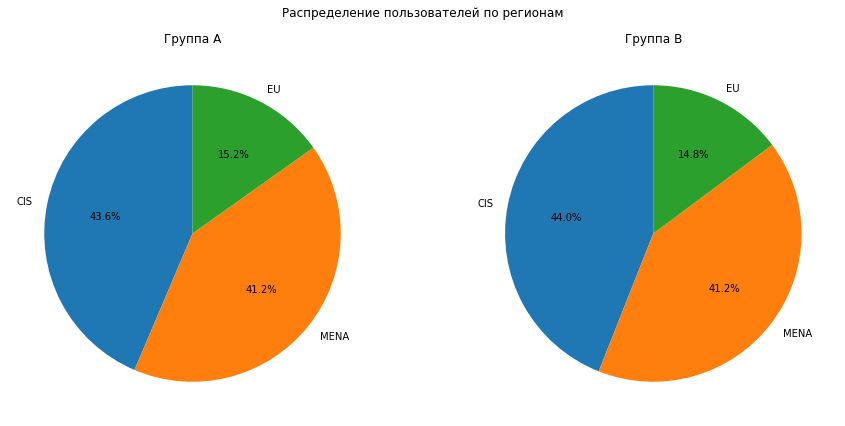

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, group in zip(axes, [control_group, test_group]):
    values = region_shares.loc[group].sort_values(ascending=False)
    ax.pie(values, labels=values.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Группа {group}')
fig.suptitle('Распределение пользователей по регионам')
plt.tight_layout()
plt.show()

Распределения в группах А и Б по региону также небольшое, расхождение: регион CIS - 0.4% ; регион EU - 0.4%, MENA - нет различий.

In [23]:
device_max_diff_pp = 100 * abs(
    device_shares.loc[control_group] - device_shares.loc[test_group]
).max()
region_max_diff_pp = 100 * abs(
    region_shares.loc[control_group] - region_shares.loc[test_group]
).max()

print(f"Максимальное расхождение в группах по используемому девайсу: {device_max_diff_pp:.3f}%")
print(f"Максимальное расхождение в группах по региону: {region_max_diff_pp:.3f}%")

Максимальное расхождение в группах по используемому девайсу: 1.691%
Максимальное расхождение в группах по региону: 0.395%


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

Разница в числе пользователей групп составила 0.74%. Пересечений нет, выборки независимы. Максимальное расхождение долей по устройствам 1.69%, по регионам 0.4%; распределения близки. A/B тест проходит корректно, никаких серьезных нарушений не наблюдается

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [24]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

sessions_test['good_session'] = sessions_test['page_counter'].ge(4).astype(int)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

<b>Основная метрика</b> - доля пользователей, у которых первая сессия была успешно, т.е. просмотр не менее 4-х страниц

* <b>Нулевая гипотеза (H0)</b> - новый алгоритм не увеличивает долю успешных первых сессий
* <b>Альтернативная гипотеза (H1)</b> - новый алгоритм увеличивает долю успешных сессий

В качестве прокси-метрик можно отслеживать число страниц за сессию, долю просмотров более 80% видео, среднее время просмотра

В качестве барьерных метрик можно использовать выходы после рекламной вставки, коверсия подписки, доля отмененных подписок, жалобы.

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [25]:
first_sessions = sessions_test[
    sessions_test['session_number'] == 1
]

metric_by_group = (
    first_sessions
    .groupby('test_group')['good_session']
    .agg(
        successful='sum',
        users='count',
        share='mean'
    )
)

In [26]:
control_group = metric_by_group.loc['A', 'share']
test_group = metric_by_group.loc['B', 'share']
share_difference = (test_group - control_group)

In [27]:
print(f'Разница {test_group:.4f} − {control_group:.4f}: {share_difference:.3%}')

Разница 0.3147 − 0.3157: -0.105%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доля успешных первых сессий для выборок A и B ухудшилась на 0.1%, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [28]:
stat_ztest, p_value_ztest = proportions_ztest(
    metric_by_group['successful'].to_numpy(),
    metric_by_group['users'].to_numpy(),
    alternative='smaller'
)

print(f'z-статистика: {stat_ztest:.2f}')
print(f'p-value: {p_value_ztest:.2f}')

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

z-статистика: 0.20
p-value: 0.58
pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза находит подтверждение!


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Рассчитанная минимальная длительность A/B-теста составила 9 дней. Фактически тест длился 20 дней с 14/10/2025 по 02/11/2025. В анализе участвовало 82_082 пользователей. Доля успешных первых сессий в группе А составила 31.57%, в группе В - 31.47%. Основная метрика снизилась на 0.1%.

В результате одностороннего z-теста было получено значение p-value=0.578, уровень значимости при этом 0.05 -> эффект статитчески незначим.

<b>Доказательств улучшения от внедрения алгоритма нет, внедрять его не стоит</b>